In [1]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

Headlights: 2 gaussian blobs same covariance with some overlap, 1 class each

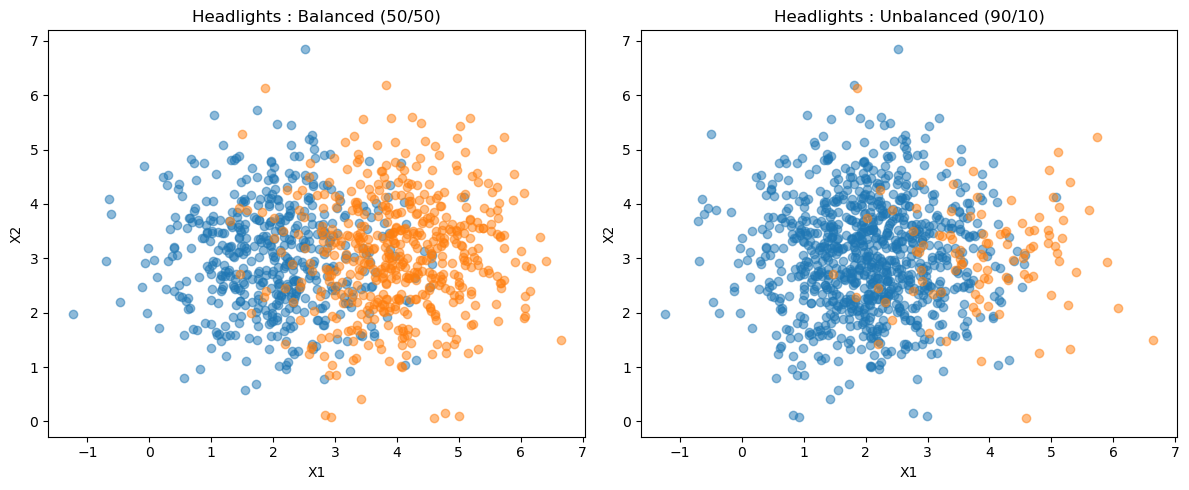

In [2]:
#balanced
X_headlights_balanced, y_headlights_balanced=make_blobs(n_samples=[500,500], centers=[[2,3],[4,3]],cluster_std=1.0, random_state=42)


#unbalanced
X_headlights_unbalanced, y_headlights_unbalanced=make_blobs(n_samples=[900,100], centers=[[2,3],[4,3]],cluster_std=1.0, random_state=42)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_headlights_balanced[y_headlights_balanced == 0, 0], X_headlights_balanced[y_headlights_balanced == 0, 1], alpha=0.5, label='Classe 0 (50%)')
plt.scatter(X_headlights_balanced[y_headlights_balanced == 1, 0], X_headlights_balanced[y_headlights_balanced == 1, 1], alpha=0.5, label='Classe 1 (50%)')
plt.title('Headlights : Balanced (50/50)')
plt.xlabel('X1')
plt.ylabel('X2')

plt.subplot(1, 2, 2)
plt.scatter(X_headlights_unbalanced[y_headlights_unbalanced == 0, 0], X_headlights_unbalanced[y_headlights_unbalanced == 0, 1], alpha=0.5, label='Classe 0 (90%)')
plt.scatter(X_headlights_unbalanced[y_headlights_unbalanced == 1, 0], X_headlights_unbalanced[y_headlights_unbalanced == 1, 1], alpha=0.5, label='Classe 1 (10%)')
plt.title('Headlights : Unbalanced (90/10)')
plt.xlabel('X1')
plt.ylabel('X2')

plt.tight_layout()
plt.show()

Shell: 1 circular gaussian blob (class A) and one somewhat rectangular thin strip of points with the
width of the blob (class B) slightly overlapping the edge of the blob. Balanced classes.


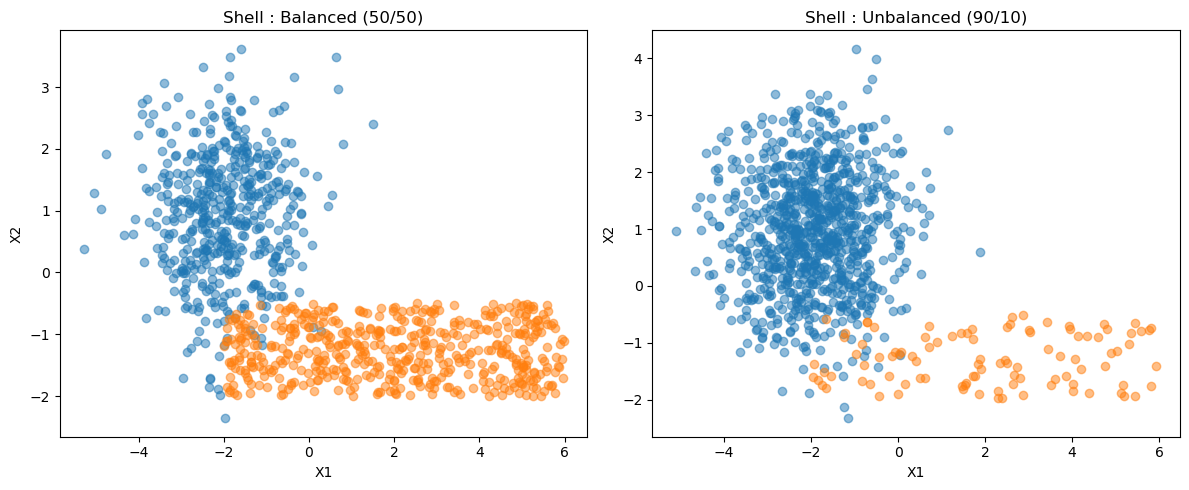

In [3]:
#balanced
# 2. CLASSE A
class_a = np.random.multivariate_normal([-2, 1],[[1, 0], [0, 1]],  500)
y_a = np.zeros(500)

# 2. CLASSE B
x_rect = np.random.uniform(-2, 6, 500) 
y_rect = np.random.uniform(-2, -0.5, 500)
class_b = np.column_stack((x_rect, y_rect))

y_b=np.ones(500)

X_shell_balanced, y_shell_balanced = np.vstack([class_a,class_b]), np.hstack([y_a,y_b])


#unbalanced
# 2. CLASSE A
class_a = np.random.multivariate_normal([-2, 1],[[1, 0], [0, 1]],  900)
y_a=np.zeros(900)

# 2. CLASSE B
x_rect = np.random.uniform(-2, 6, 100) 
y_rect = np.random.uniform(-2, -0.5, 100)
class_b = np.column_stack((x_rect, y_rect))
y_b=np.ones(100)

X_shell_unbalanced, y_shell_unbalanced = np.vstack([class_a,class_b]), np.hstack([y_a,y_b])



plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_shell_balanced[y_shell_balanced == 0, 0], X_shell_balanced[y_shell_balanced == 0, 1], alpha=0.5, label='Classe 0 (50%)')
plt.scatter(X_shell_balanced[y_shell_balanced == 1, 0], X_shell_balanced[y_shell_balanced == 1, 1], alpha=0.5, label='Classe 1 (50%)')
plt.title('Shell : Balanced (50/50)')
plt.xlabel('X1')
plt.ylabel('X2')

plt.subplot(1, 2, 2)
plt.scatter(X_shell_unbalanced[y_shell_unbalanced == 0, 0], X_shell_unbalanced[y_shell_unbalanced == 0, 1], alpha=0.5, label='Classe 0 (90%)')
plt.scatter(X_shell_unbalanced[y_shell_unbalanced == 1, 0], X_shell_unbalanced[y_shell_unbalanced == 1, 1], alpha=0.5, label='Classe 1 (10%)')
plt.title('Shell : Unbalanced (90/10)')
plt.xlabel('X1')
plt.ylabel('X2')

plt.tight_layout()
plt.show()

DD: 1 half circular blob, D shaped (class A) and another similar one to the right almost touching but
with almost no or minimal overlaping (class B)

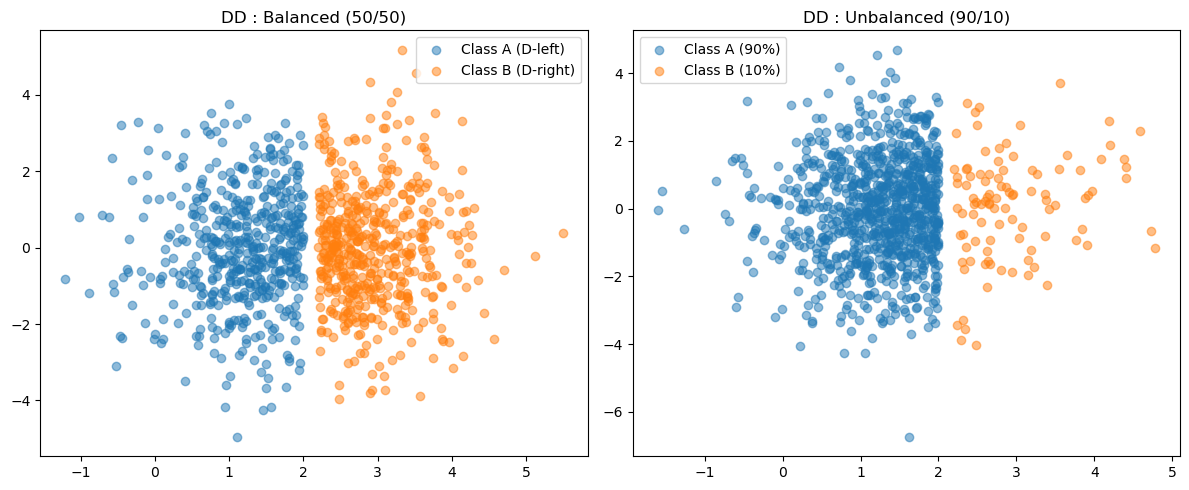

In [4]:
def generate_d_shape(n_samples, center_x=0, center_y=0, direction='left'):
    d_points = np.empty((0, 2))  # Initialise un tableau vide à 2 colonnes
    
    while len(d_points) < n_samples:
        needed = n_samples - len(d_points)
        batch_size = int(needed * 2) 
        
        points = np.random.normal(loc=[center_x, center_y], 
                                  scale=[1.0, 1.5], 
                                  size=(batch_size, 2))
        
        if direction == 'left':
            filtered = points[points[:, 0] <= center_x]
        else:
            filtered = points[points[:, 0] >= center_x]
        
        d_points = np.vstack([d_points, filtered])

    return d_points[:n_samples]

# balanced
class_a_bal = generate_d_shape(500, center_x=2, direction='left')
class_b_bal = generate_d_shape(500, center_x=2.2, direction='right') # Petit écart pour presque toucher

X_DD_balanced = np.vstack([class_a_bal, class_b_bal])
y_DD_balanced = np.hstack([np.zeros(500), np.ones(500)])

# Unbalanced
class_a_unbal = generate_d_shape(900, center_x=2, direction='left')
class_b_unbal = generate_d_shape(100, center_x=2.2, direction='right')

X_DD_unbalanced = np.vstack([class_a_unbal, class_b_unbal])
y_DD_unbalanced = np.hstack([np.zeros(900), np.ones(100)])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_DD_balanced[y_DD_balanced==0, 0], X_DD_balanced[y_DD_balanced==0, 1], alpha=0.5, label='Class A (D-left)')
plt.scatter(X_DD_balanced[y_DD_balanced==1, 0], X_DD_balanced[y_DD_balanced==1, 1], alpha=0.5, label='Class B (D-right)')
plt.title('DD : Balanced (50/50)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_DD_unbalanced[y_DD_unbalanced==0, 0], X_DD_unbalanced[y_DD_unbalanced==0, 1], alpha=0.5, label='Class A (90%)')
plt.scatter(X_DD_unbalanced[y_DD_unbalanced==1, 0], X_DD_unbalanced[y_DD_unbalanced==1, 1], alpha=0.5, label='Class B (10%)')
plt.title('DD : Unbalanced (90/10)')
plt.legend()

plt.tight_layout()
plt.show()

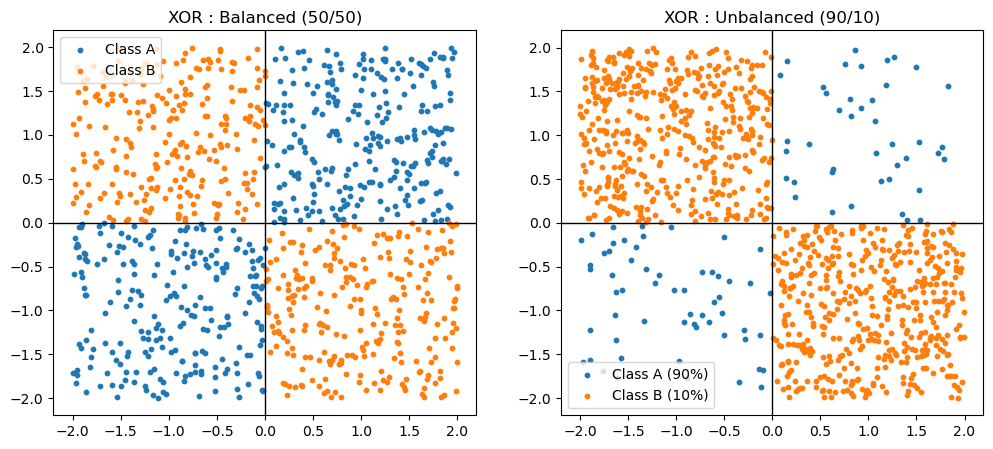

In [5]:
def generate_xor(n_samples, p_balanced=0.5):
    n_class_b = int(n_samples * (1 - p_balanced))
    n_class_a = n_samples - n_class_b
    
    X = np.random.uniform(-2, 2, (n_samples * 10, 2))

    labels = (X[:, 0] > 0) ^ (X[:, 1] > 0)
    
    X_a = X[labels == 0]
    X_b = X[labels == 1]
    
    X_final = np.vstack([X_a[:n_class_a], X_b[:n_class_b]])
    y_final = np.hstack([np.zeros(n_class_a), np.ones(n_class_b)])
    
    return X_final, y_final

# Balanced
X_xor_balanced, y_xor_balanced = generate_xor(1000, p_balanced=0.5)

# Unbalanced
X_xor_unbalanced, y_xor_unbalanced = generate_xor(1000, p_balanced=0.1)

# --- Affichage ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_xor_balanced[y_xor_balanced==0, 0], X_xor_balanced[y_xor_balanced==0, 1], s=10, label='Class A')
plt.scatter(X_xor_balanced[y_xor_balanced==1, 0], X_xor_balanced[y_xor_balanced==1, 1], s=10, label='Class B')
plt.title("XOR : Balanced (50/50)")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_xor_unbalanced[y_xor_unbalanced==0, 0], X_xor_unbalanced[y_xor_unbalanced==0, 1], s=10, label='Class A (90%)')
plt.scatter(X_xor_unbalanced[y_xor_unbalanced==1, 0], X_xor_unbalanced[y_xor_unbalanced==1, 1], s=10, label='Class B (10%)')
plt.title("XOR : Unbalanced (90/10)")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.legend()

plt.show()

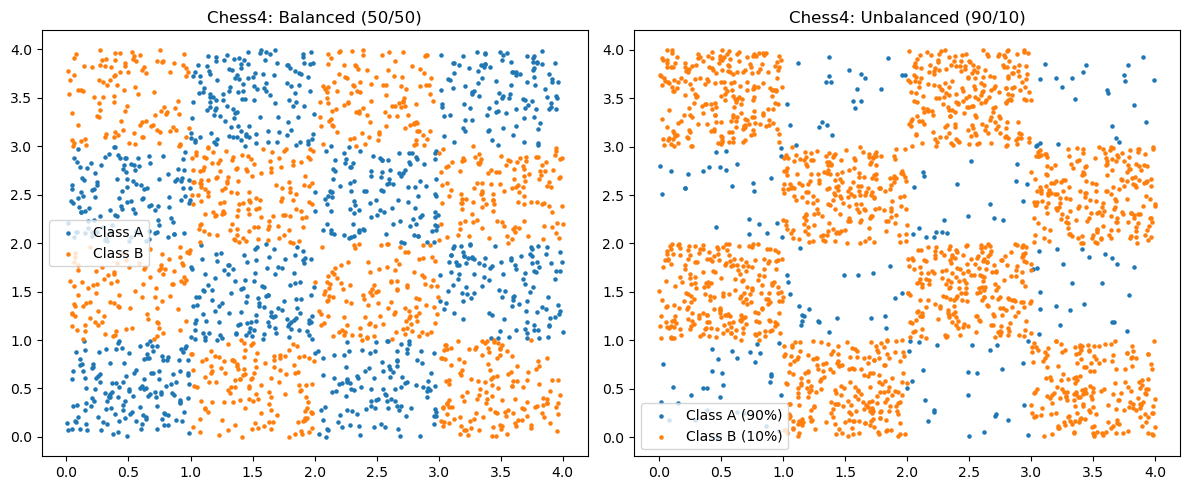

In [6]:
def generate_chess4(n_samples, p_balanced=0.5):
    n_class_b = int(n_samples * (1 - p_balanced))
    n_class_a = n_samples - n_class_b
    
    X_pool = np.random.uniform(0, 4, (n_samples * 10, 2))

    logic = (np.floor(X_pool[:, 0]).astype(int) + np.floor(X_pool[:, 1]).astype(int)) % 2
    
    X_a = X_pool[logic == 0]
    X_b = X_pool[logic == 1]
    
    X_final = np.vstack([X_a[:n_class_a], X_b[:n_class_b]])
    y_final = np.hstack([np.zeros(n_class_a), np.ones(n_class_b)])
    
    return X_final, y_final

# Balanced
X_chess4_balanced, y_chess4_balanced = generate_chess4(2000, p_balanced=0.5)

# Unbalanced
X_chess4_unbalanced, y_chess4_unbalanced = generate_chess4(2000, p_balanced=0.1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_chess4_balanced[y_chess4_balanced==0, 0], X_chess4_balanced[y_chess4_balanced==0, 1], s=5, label='Class A')
plt.scatter(X_chess4_balanced[y_chess4_balanced==1, 0], X_chess4_balanced[y_chess4_balanced==1, 1], s=5, label='Class B')
plt.title("Chess4: Balanced (50/50)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_chess4_unbalanced[y_chess4_unbalanced==0, 0], X_chess4_unbalanced[y_chess4_unbalanced==0, 1], s=5, label='Class A (90%)')
plt.scatter(X_chess4_unbalanced[y_chess4_unbalanced==1, 0], X_chess4_unbalanced[y_chess4_unbalanced==1, 1], s=5, label='Class B (10%)')
plt.title("Chess4: Unbalanced (90/10)")
plt.legend()

plt.tight_layout()
plt.show()

Roseta2: 1 round central blob (class A), 1 ring around the central blob, like a blob without the central
part, where class A is (class B)


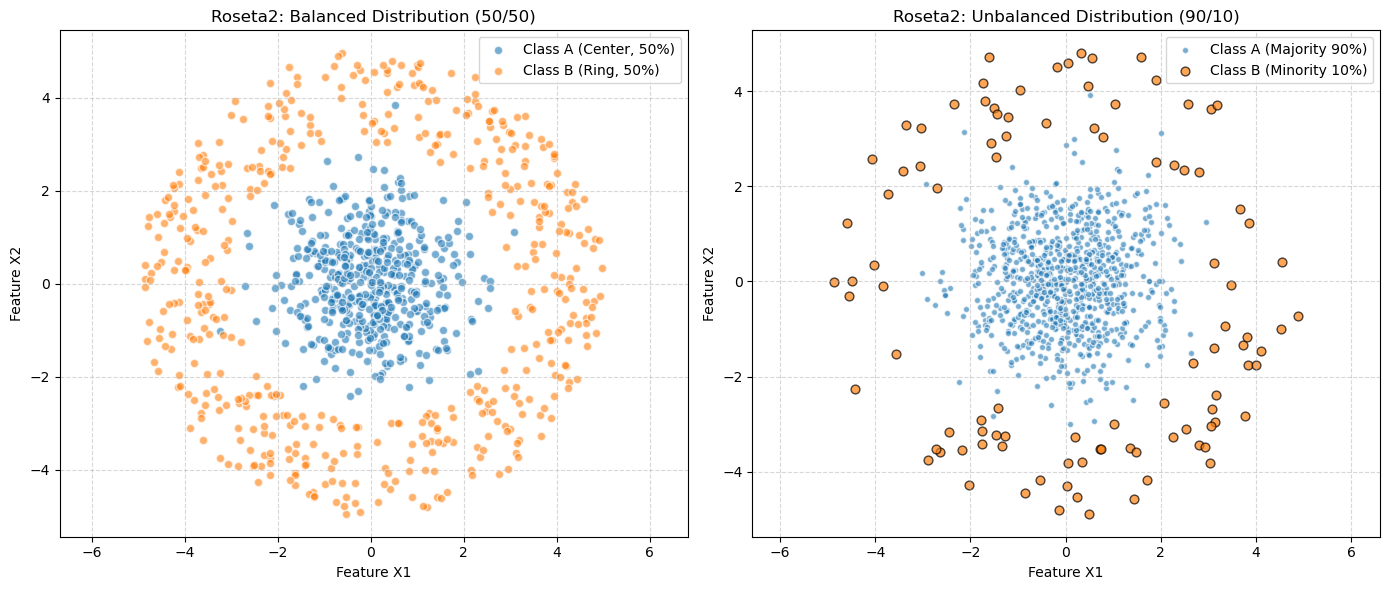

In [7]:
def generate_roseta2_dataset(n_samples, p_balanced=0.5):

    n_samples_b = int(n_samples * (1 - p_balanced))
    n_samples_a = n_samples - n_samples_b
    
    center = [0, 0]

    cluster_std = 1.0
    X_a = np.random.normal(loc=center, scale=cluster_std, size=(n_samples_a, 2))
    
    r_min = 3.0
    r_max = 5.0
    
    theta = np.random.uniform(0, 2 * np.pi, n_samples_b)
    
    r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_samples_b))
    
    x_ring = center[0] + r * np.cos(theta)
    y_ring = center[1] + r * np.sin(theta)
    X_b = np.column_stack((x_ring, y_ring))

    X_final = np.vstack([X_a, X_b])
    y_final = np.hstack([np.zeros(n_samples_a), np.ones(n_samples_b)])
    
    return X_final, y_final

total_samples = 1000
np.random.seed(42)

# Balanced
X_roseta_balanced, y_roseta_balanced = generate_roseta2_dataset(total_samples, p_balanced=0.5)

# Unbalanced
X_roseta_unbalanced, y_roseta_unbalanced = generate_roseta2_dataset(total_samples, p_balanced=0.9)

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)

plt.scatter(X_roseta_balanced[y_roseta_balanced == 0, 0], 
            X_roseta_balanced[y_roseta_balanced == 0, 1], 
            alpha=0.6, label='Class A (Center, 50%)', edgecolors='w')
plt.scatter(X_roseta_balanced[y_roseta_balanced == 1, 0], 
            X_roseta_balanced[y_roseta_balanced == 1, 1], 
            alpha=0.6, label='Class B (Ring, 50%)', edgecolors='w')

plt.title('Roseta2: Balanced Distribution (50/50)')
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

plt.subplot(1, 2, 2)

plt.scatter(X_roseta_unbalanced[y_roseta_unbalanced == 0, 0], 
            X_roseta_unbalanced[y_roseta_unbalanced == 0, 1], 
            alpha=0.6, label='Class A (Majority 90%)', edgecolors='w', s=20)

plt.scatter(X_roseta_unbalanced[y_roseta_unbalanced == 1, 0], 
            X_roseta_unbalanced[y_roseta_unbalanced == 1, 1], 
            alpha=0.7, label='Class B (Minority 10%)', edgecolors='k', s=40, marker='o')

plt.title('Roseta2: Unbalanced Distribution (90/10)')
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

plt.tight_layout()
plt.show()

 Roseta3: Same as above, but 3 concentric rings with 2 aalternating classes


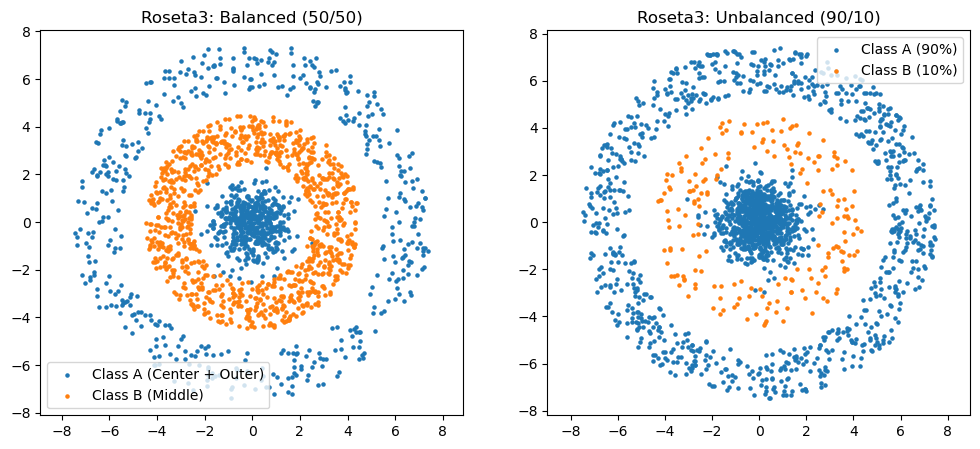

In [8]:
def generate_roseta3(n_samples, p_class_a=0.5):

    n_samples_a = int(n_samples * p_class_a)
    n_samples_b = n_samples - n_samples_a
    
    n_a_center = n_samples_a // 2
    n_a_outer = n_samples_a - n_a_center
    
    X_a_center = np.random.normal(loc=[0, 0], scale=0.8, size=(n_a_center, 2))
    
    r_min2, r_max2 = 2.5, 4.5
    theta2 = np.random.uniform(0, 2 * np.pi, n_samples_b)
    r2 = np.sqrt(np.random.uniform(r_min2**2, r_max2**2, n_samples_b))
    X_b_middle = np.column_stack((r2 * np.cos(theta2), r2 * np.sin(theta2)))
    
    r_min3, r_max3 = 5.5, 7.5
    theta3 = np.random.uniform(0, 2 * np.pi, n_a_outer)
    r3 = np.sqrt(np.random.uniform(r_min3**2, r_max3**2, n_a_outer))
    X_a_outer = np.column_stack((r3 * np.cos(theta3), r3 * np.sin(theta3)))
    
    X_roseta3_a = np.vstack([X_a_center, X_a_outer])
    X_roseta3_b = X_b_middle
    
    X_final = np.vstack([X_roseta3_a, X_roseta3_b])
    y_final = np.hstack([np.zeros(len(X_roseta3_a)), np.ones(len(X_roseta3_b))])
    
    return X_final, y_final

# Balanced
X_roseta3_balanced, y_roseta3_balanced = generate_roseta3(2000, p_class_a=0.5)

# Unbalanced
X_roseta3_unbalanced, y_roseta3_unbalanced = generate_roseta3(2000, p_class_a=0.9)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_roseta3_balanced[y_roseta3_balanced==0, 0], X_roseta3_balanced[y_roseta3_balanced==0, 1], s=5, label='Class A (Center + Outer)')
plt.scatter(X_roseta3_balanced[y_roseta3_balanced==1, 0], X_roseta3_balanced[y_roseta3_balanced==1, 1], s=5, label='Class B (Middle)')
plt.title("Roseta3: Balanced (50/50)")
plt.axis('equal')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_roseta3_unbalanced[y_roseta3_unbalanced==0, 0], X_roseta3_unbalanced[y_roseta3_unbalanced==0, 1], s=5, label='Class A (90%)')
plt.scatter(X_roseta3_unbalanced[y_roseta3_unbalanced==1, 0], X_roseta3_unbalanced[y_roseta3_unbalanced==1, 1], s=5, label='Class B (10%)')
plt.title("Roseta3: Unbalanced (90/10)")
plt.axis('equal')
plt.legend()

plt.show()

Test of the differents model trained on the datasets

In [9]:
X_balanced = [X_headlights_balanced, X_shell_balanced, X_DD_balanced, X_xor_balanced, X_chess4_balanced, X_roseta_balanced , X_roseta3_balanced]
X_unbalanced =[X_headlights_unbalanced, X_shell_unbalanced, X_DD_unbalanced, X_xor_unbalanced, X_chess4_unbalanced, X_roseta_unbalanced, X_roseta3_unbalanced]
y_balanced = [y_headlights_balanced, y_shell_balanced, y_DD_balanced, y_xor_balanced, y_chess4_balanced, y_roseta_balanced , y_roseta3_balanced]
y_unbalanced = [y_headlights_unbalanced, y_shell_unbalanced, y_DD_unbalanced, y_xor_unbalanced, y_chess4_unbalanced, y_roseta_unbalanced, y_roseta3_unbalanced]

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

models = {
    "1NN": KNeighborsClassifier(n_neighbors=1),
    "5NN": KNeighborsClassifier(n_neighbors=5),
    "10NN": KNeighborsClassifier(n_neighbors=10),
    "Logistic Regression": LogisticRegression(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}
accuracy_balanced = {}
recall_balanced = {}
f1_balanced = {}
precision_balanced = {}
for name in models.keys():
    accuracy_balanced[name] = []
    recall_balanced[name] = []
    f1_balanced[name] = []
    precision_balanced[name] = []

for i in range(len(X_balanced)):

    X,y=X_balanced[i],y_balanced[i]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracy_balanced[name].append(acc)
        rec = recall_score(y_test,y_pred)
        recall_balanced[name].append(rec)
        f1 = f1_score(y_test,y_pred)
        f1_balanced[name].append(f1)
        prec = precision_score(y_test,y_pred)
        precision_balanced[name].append(prec)

accuracy_unbalanced = {}
recall_unbalanced = {}
f1_unbalanced = {}
precision_unbalanced = {}
for name in models.keys():
    accuracy_unbalanced[name] = []
    recall_unbalanced[name] = []
    f1_unbalanced[name] = []
    precision_unbalanced[name] = []

for i in range(len(X_balanced)):

    X,y=X_unbalanced[i],y_unbalanced[i]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        accuracy_unbalanced[name].append(acc)
        rec = recall_score(y_test, y_pred)
        recall_unbalanced[name].append(rec)
        f1 = f1_score(y_test, y_pred)
        f1_unbalanced[name].append(f1)
        prec = precision_score(y_test,y_pred)
        precision_unbalanced[name].append(prec)


   

c:\Users\Lenovo\anaconda3\envs\FPROG\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\anaconda3\envs\FPROG\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\anaconda3\envs\FPROG\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\anaconda3\envs\FPROG\lib\site-packages\sklearn\metrics\_classifica

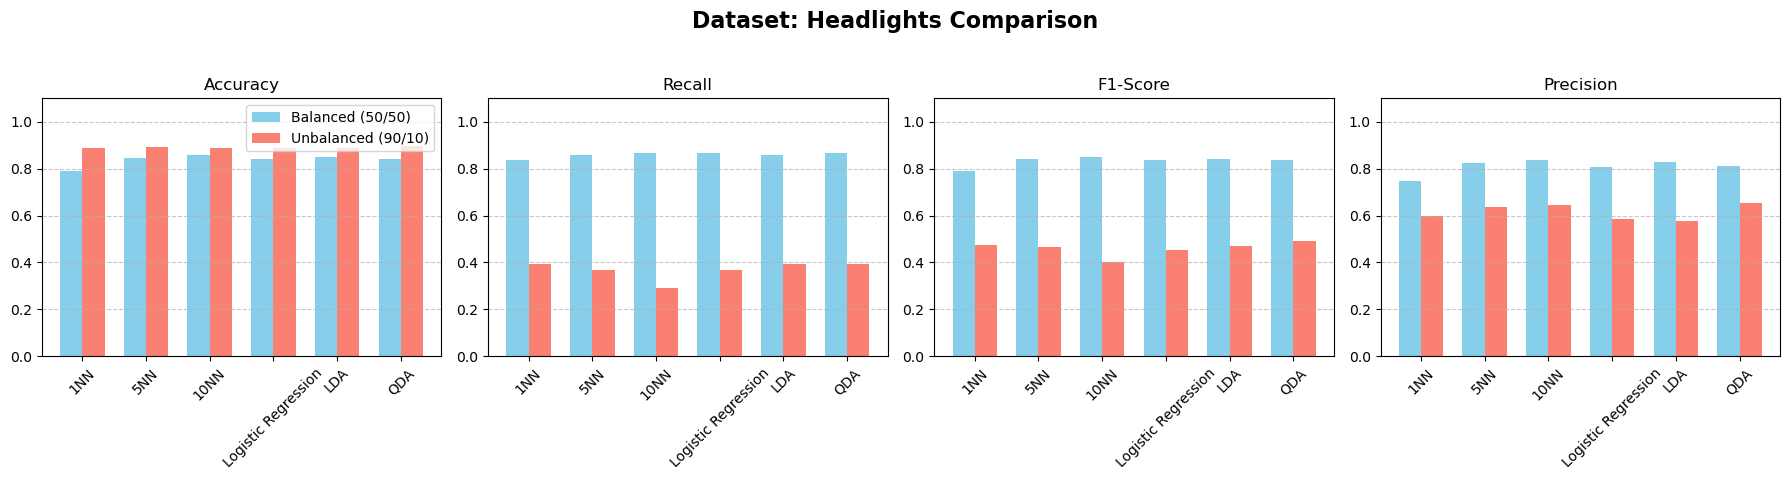

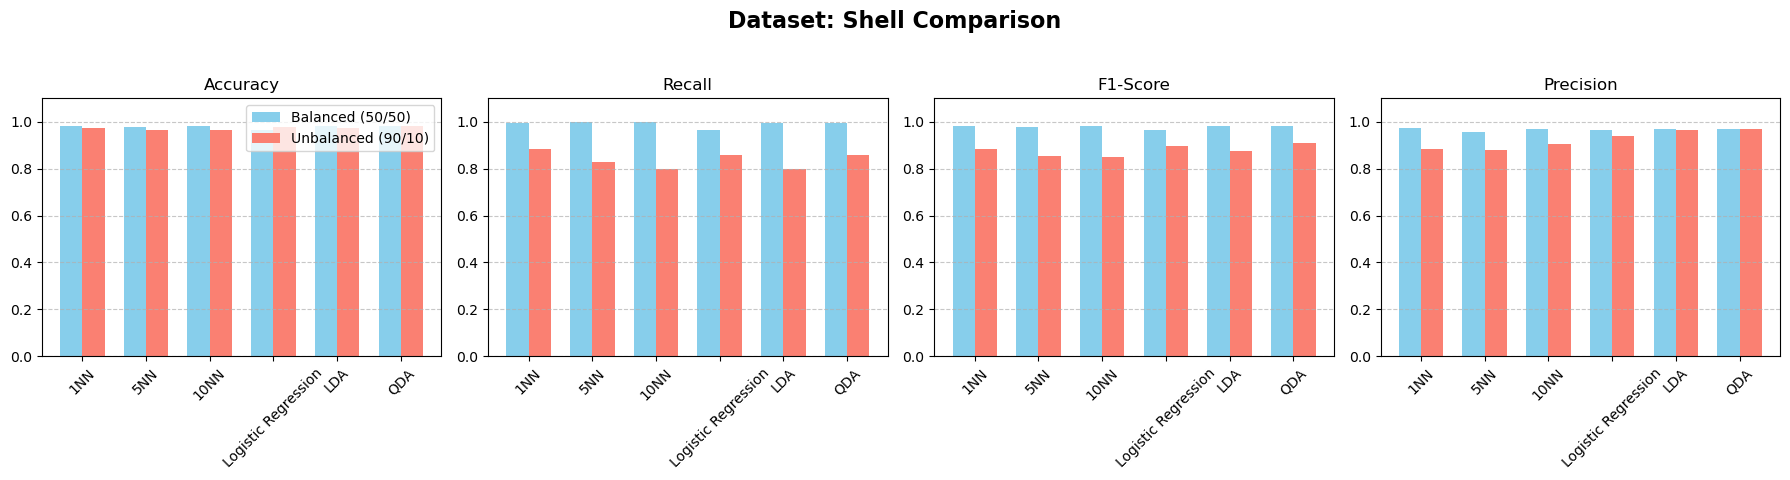

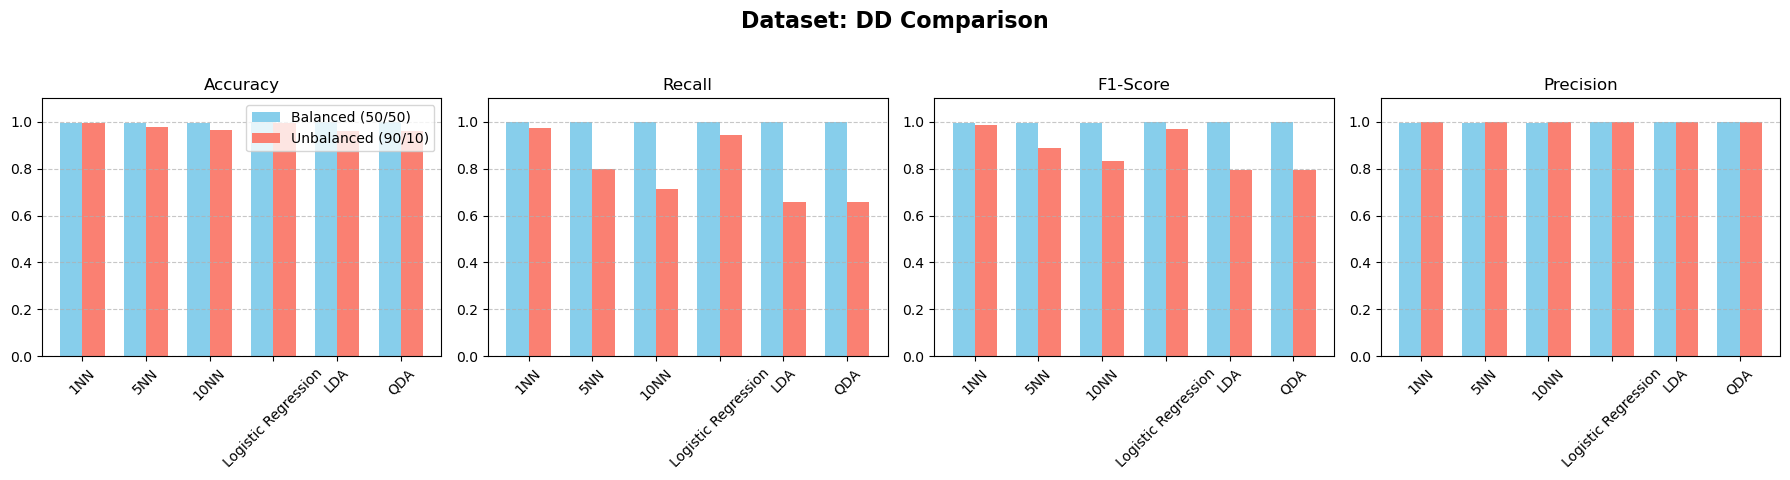

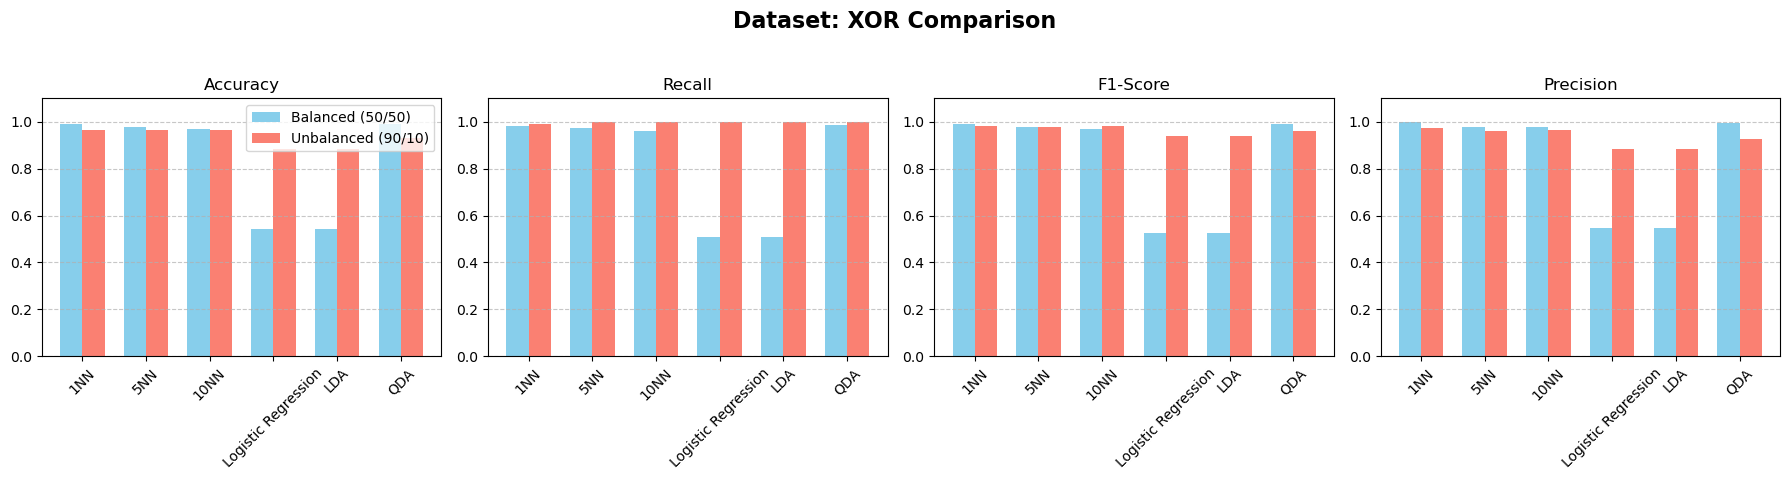

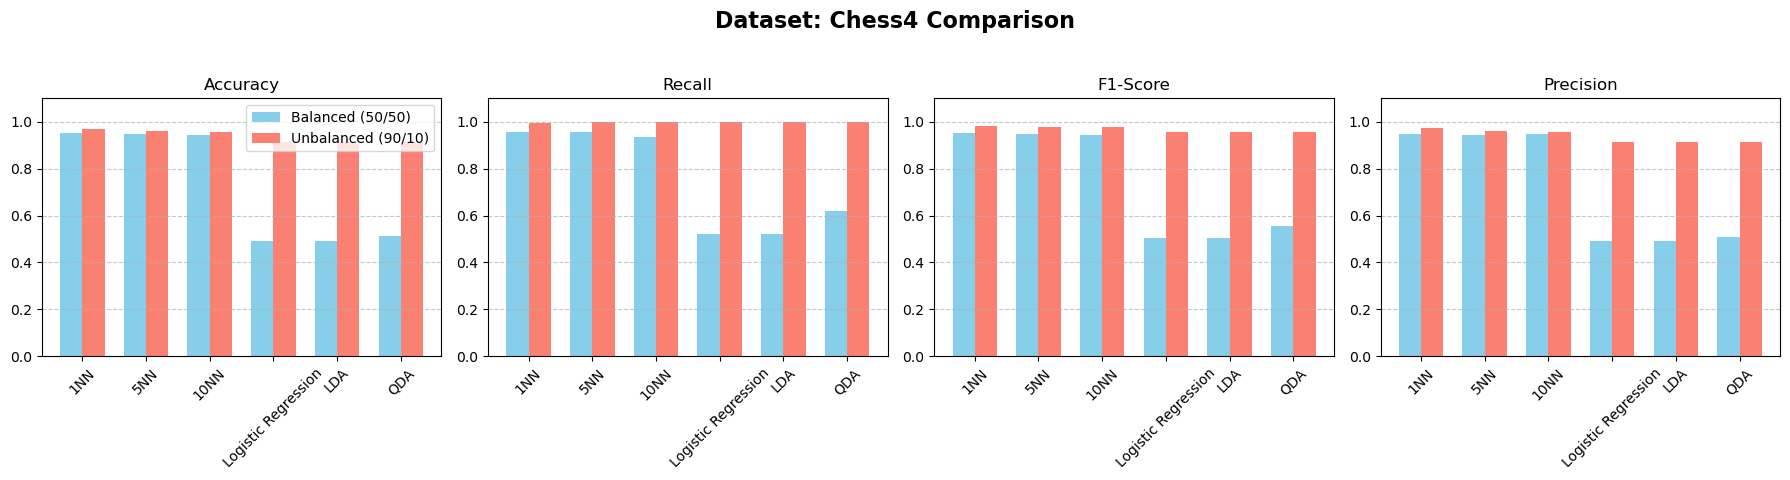

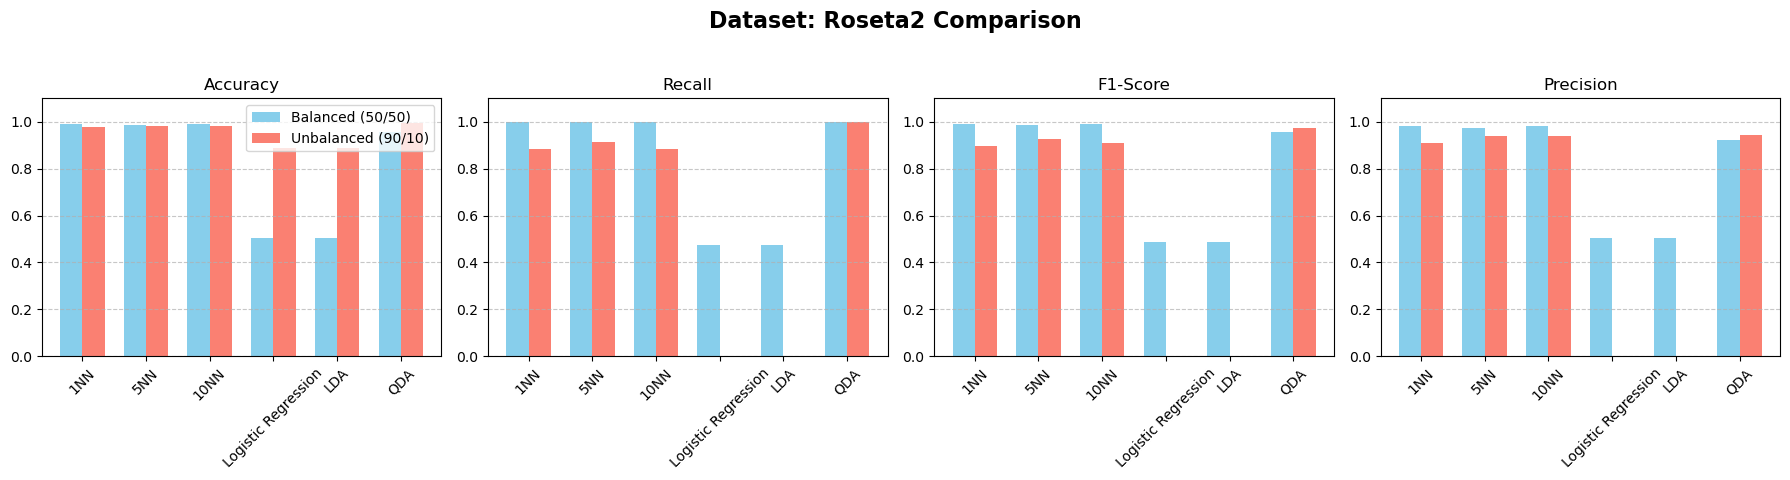

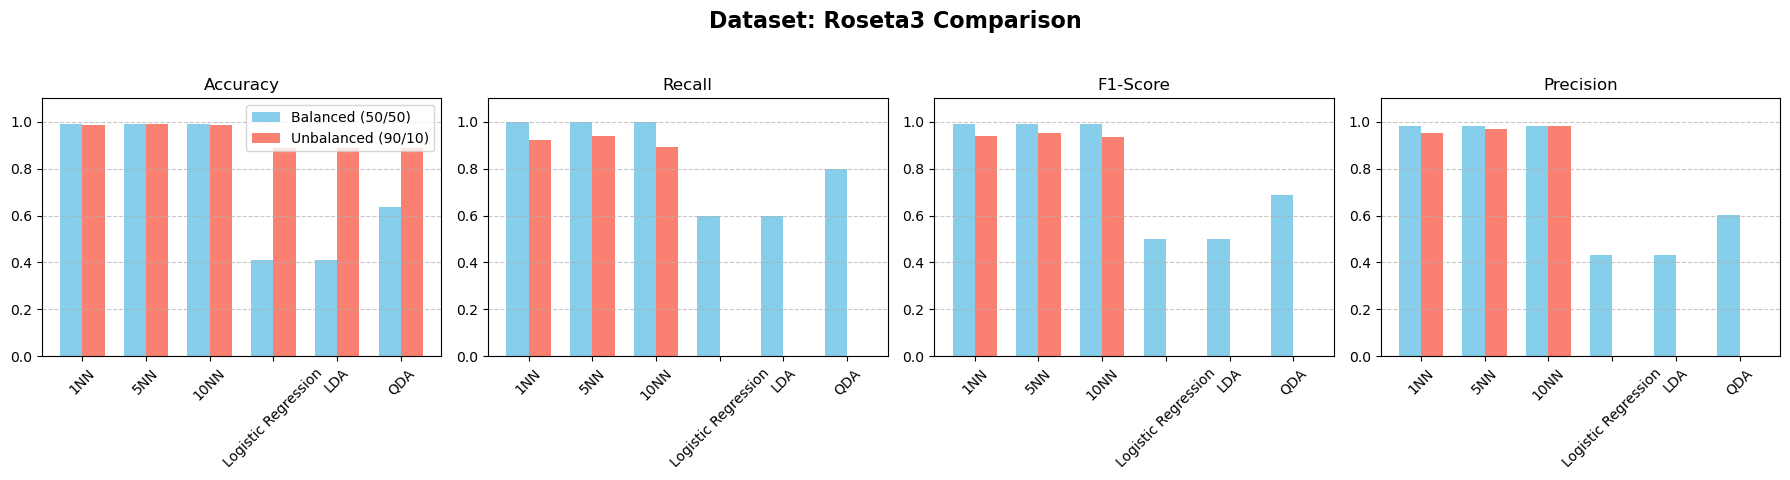

In [11]:
import pandas as pd

dataset_names = ["Headlights", "Shell", "DD", "XOR", "Chess4", "Roseta2", "Roseta3"]
metrics = ['Accuracy', 'Recall', 'F1-Score','Precision']

for i in range(len(dataset_names)):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Dataset: {dataset_names[i]} Comparison", fontsize=16, fontweight='bold')

    data_bal = {
        'Model': list(models.keys()),
        'Accuracy': [accuracy_balanced[m][i] for m in models],
        'Recall': [recall_balanced[m][i] for m in models],
        'F1-Score': [f1_balanced[m][i] for m in models],
        'Precision': [precision_balanced[m][i] for m in models]
    }
    
    data_unbal = {
        'Model': list(models.keys()),
        'Accuracy': [accuracy_unbalanced[m][i] for m in models],
        'Recall': [recall_unbalanced[m][i] for m in models],
        'F1-Score': [f1_unbalanced[m][i] for m in models],
        'Precision': [precision_unbalanced[m][i] for m in models]
    }

    df_bal = pd.DataFrame(data_bal)
    df_unbal = pd.DataFrame(data_unbal)
    
    for j, metric in enumerate(['Accuracy', 'Recall', 'F1-Score', 'Precision']):
        x = np.arange(len(models))
        width = 0.35

        axes[j].bar(x - width/2, df_bal[metric], width, label='Balanced (50/50)', color='skyblue')
        axes[j].bar(x + width/2, df_unbal[metric], width, label='Unbalanced (90/10)', color='salmon')

        axes[j].set_title(f'{metric}')
        axes[j].set_xticks(x)
        axes[j].set_xticklabels(df_bal['Model'], rotation=45)
        axes[j].set_ylim(0, 1.1)
        axes[j].grid(axis='y', linestyle='--', alpha=0.7)
        if j == 0: axes[j].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

#add precision
decision boundary
put everithing in a function so we can improve

# 2nd LEG

## 2.1. Preparing Data

In [12]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data():
    # 1. Load dataset
    raw_data = load_breast_cancer()
    X, y = raw_data.data, raw_data.target
    
    # 2. Test/Train split (70/30)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 3. Normalization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# Perform Preparation
X_train, X_test, y_train, y_test = prepare_data()


# 2.2 Bias, Variance and Total Error decomposition

In [13]:
from sklearn.utils import resample

def bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=100):
    """
    Performs manual bootstrapping to estimate Total Error, Bias, and Variance 
    using the 0-1 Loss formulation for classification tasks.
    """
    n_test_samples = len(X_test)
    # Matrix to store predictions: (rows = bootstrap rounds, columns = test samples)
    all_predictions = np.zeros((n_bootstraps, n_test_samples))
    
    # Manual Bootstrap Loop
    for i in range(n_bootstraps):
        # Generate a bootstrap sample from the training set (with replacement)
        X_boot, y_boot = resample(X_train, y_train, random_state=i)
        
        # Train the model on the bootstrap sample and predict on the fixed test set
        model.fit(X_boot, y_boot)
        all_predictions[i, :] = model.predict(X_test)
    
    # --- Statistical Calculations (0-1 Classification Loss) ---
    
    # 1. Total Average Error (proportion of misclassifications across all rounds)
    # Numpy broadcasting compares the (n_bootstraps, n_test) matrix with the (n_test,) y_test vector
    total_error = np.mean(all_predictions != y_test)
    
    # 2. Main Prediction (Majority vote for each test sample across all rounds)
    # Since classes are 0 and 1, a mean >= 0.5 rounded yields the majority class
    main_prediction = np.round(np.mean(all_predictions, axis=0))
    
    # 3. Bias (Proportion of times the Main Prediction differs from the actual ground truth)
    bias = np.mean(main_prediction != y_test)
    
    # 4. Variance (Average deviation of the bootstrap predictions from the Main Prediction)
    variance = np.mean(all_predictions != main_prediction)
    
    return total_error, bias, variance

# 2.3 How do Bias, Variance, and Total Error vary across different machine learning families under a fixed set of baseline hyperparameters?

It demonstrates the intrinsic "inductive biases" of each method:

 Critical Theoretical Check (0-1 Loss Classification):
 Total Error is calculated empirically from the global misclassification rate. 
 Due to Pedro Domingos' formulation for classification, Total Error is NOT a simple 
 linear sum of global Bias and Variance. Variance can act beneficially (reducing 
 total error) on instances where the main prediction is heavily biased.

Model                          | Total Error  | Bias         | Variance    
---------------------------------------------------------------------------
Decision Tree (Complex)        | 0.0883       | 0.0526       | 0.0733
Random Forest (Ensemble)       | 0.0586       | 0.0643       | 0.0179
SVM (RBF Kernel)               | 0.0282       | 0.0175       | 0.0156
MLP (Neural Network)           | 0.0352       | 0.0351       | 0.0071


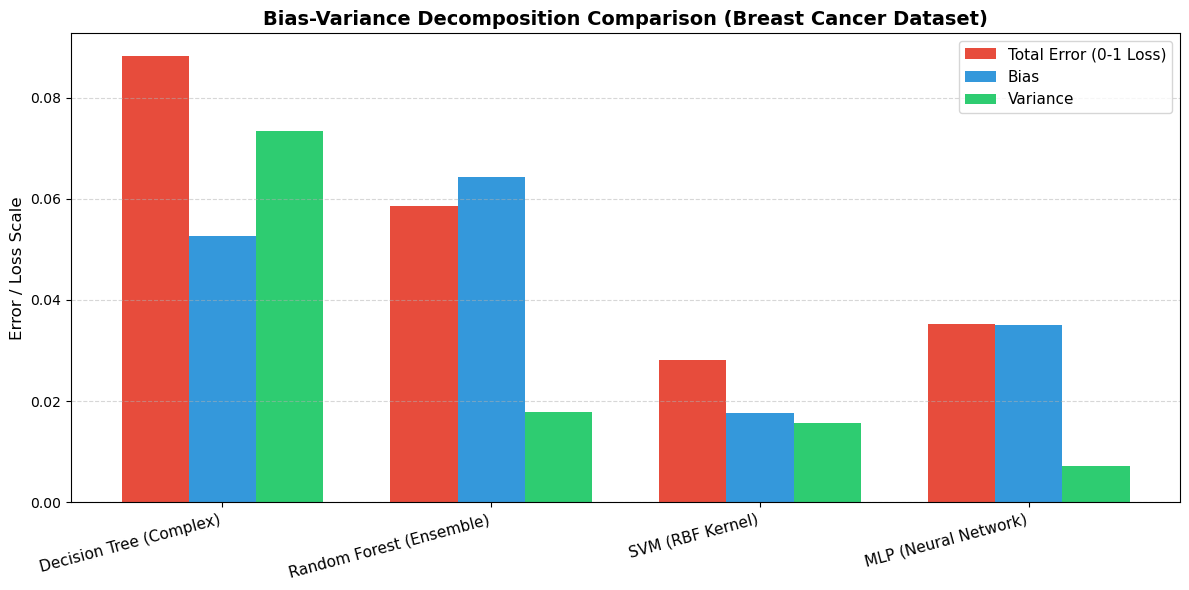

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

def run_and_plot_demonstration(X_train, X_test, y_train, y_test):
    """
    Runs the bootstrap decomposition across different models and plots the results.
    """
    # Define models with configurations that highlight their specific properties
    models = {
        "Decision Tree (Complex)": DecisionTreeClassifier(max_depth=None, random_state=42),
        "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (RBF Kernel)": SVC(C=1.0, kernel='rbf', random_state=42),
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=1000, random_state=42)
    }
    
    # Dictionaries to store metrics for plotting
    results = {}
    
    print(f"{'Model':<30} | {'Total Error':<12} | {'Bias':<12} | {'Variance':<12}")
    print("-" * 75)
    
    # Compute metrics using the bootstrap function
    for model_name, model in models.items():
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=50
        )
        results[model_name] = (total_error, bias, variance)
        print(f"{model_name:<30} | {total_error:.4f}       | {bias:.4f}       | {variance:.4f}")
        
    # --- Visualization Code ---
    model_names = list(results.keys())
    total_errors = [metrics[0] for metrics in results.values()]
    biases = [metrics[1] for metrics in results.values()]
    variances = [metrics[2] for metrics in results.values()]
    
    # Bar positions and layout configurations
    x_positions = np.arange(len(model_names))
    bar_width = 0.25  
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Render grouped bars for each metric
    ax.bar(x_positions - bar_width, total_errors, bar_width, label='Total Error (0-1 Loss)', color='#e74c3c')
    ax.bar(x_positions, biases, bar_width, label='Bias', color='#3498db')
    ax.bar(x_positions + bar_width, variances, bar_width, label='Variance', color='#2ecc71')
    
    # Customizing plot aesthetics
    ax.set_ylabel('Error / Loss Scale', fontsize=12)
    ax.set_title('Bias-Variance Decomposition Comparison (Breast Cancer Dataset)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Assumes X_train, X_test, y_train, y_test are already loaded and scaled from Step 1
run_and_plot_demonstration(X_train, X_test, y_train, y_test)

# 2.3.1 Expected Properties:

Decision Tree (Unconstrained / Deep)
- Low Bias / High Variance.Reasoning: Without restricting max_depth, a single tree will partition the feature space until it perfectly segregates the training samples (often memorizing noise). When evaluated across different bootstrap samples, its structure changes drastically, leading to high variance.Random 

Random Forest (Ensemble / Bagging)
- Low Bias / Low Variance (Significantly lower variance than the single tree).Reasoning: Bagging builds multiple unconstrained trees in parallel. While each individual tree maintains a low bias, averaging their predictions cancels out the uncorrelated errors, dramatically stabilizing the model and reducing variance.

Support Vector Machine (SVM with RBF Kernel)
- Balanced Bias and Variance (Under default settings).Reasoning: The default $C=1.0$ soft-margin parameter forces a compromise between misclassification and margin maximization. It typically achieves a highly competitive total error by preventing the decision boundary from becoming too wiggly (overfitting) or too rigid (underfitting).

Multi-Layer Perceptron (MLP / Neural Network)
- Moderate Bias / Potential for High Variance.Reasoning: Neural networks are universal approximators. With multiple hidden layers, they have enough capacity to overfit small datasets like Breast Cancer. However, standard implementation defenses (like L2 regularization/weight decay and early stopping) usually keep the variance in check.

# 2.4 How are bias and variance affected by different hyperparameters?

This part of the code aims to highlight how, for each algorithm, the variation of a specific complexity parameter directly impacts the bias and variance of the model.

2.4.0 PLOT

In [15]:

def plot_taming_curves(param_values, total_errors, biases, variances, param_name, model_name, log_scale=False):
    """
    Plots line curves to visualize how changing a hyperparameter tames bias and variance.
    """
    plt.figure(figsize=(8, 4))
    
    # Plot each metric
    plt.plot(param_values, total_errors, label='Total Error', color='#e74c3c', marker='o', linewidth=2.5)
    plt.plot(param_values, biases, label='Bias (Bias^2 equivalent)', color='#3498db', marker='s', linestyle='--')
    plt.plot(param_values, variances, label='Variance', color='#2ecc71', marker='^', linestyle='--')
    
    # Layout and labels
    plt.xlabel(param_name, fontsize=10)
    plt.ylabel('Error / Loss Scale', fontsize=10)
    plt.title(f'Taming Bias & Variance - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    if log_scale:
        plt.xscale('log')
        
    plt.tight_layout()
    plt.show()

2.4.1 DECISION TREE

Evaluating Decision Tree depths...


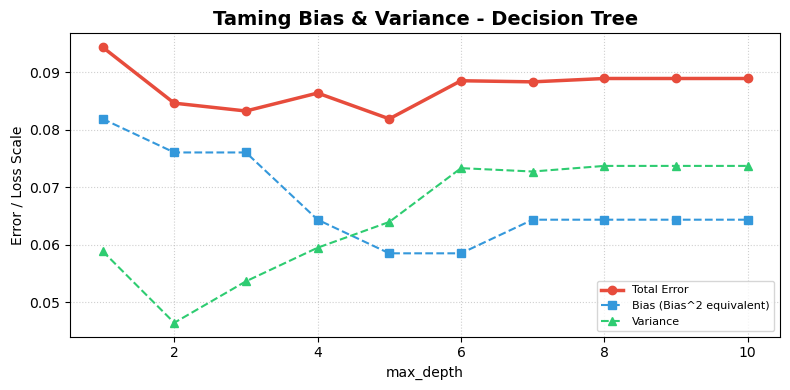

In [16]:
def tame_decision_tree(X_train, X_test, y_train, y_test):
    """
    Evaluates a Decision Tree by varying 'max_depth' to find the optimal trade-off.
    """
    # Test depths from 1 (very simple) to 10 (complex)
    depths = list(range(1, 11))
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Decision Tree depths...")
    for depth in depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        # Using 30 bootstraps to keep execution fast but statistically stable
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results
    plot_taming_curves(depths, total_errors, biases, variances, 'max_depth', 'Decision Tree')

# Run the taming process for the tree
tame_decision_tree(X_train, X_test, y_train, y_test)

2.4.2 SVM

Evaluating SVM C values...


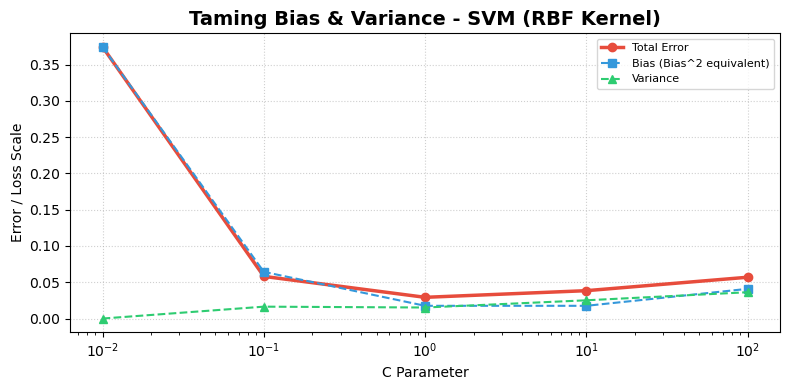

In [17]:
def tame_svm(X_train, X_test, y_train, y_test):
    """
    Evaluates an RBF SVM by varying the regularization parameter 'C'.
    """
    # Test C values on a logarithmic scale
    c_values = [0.01, 0.1, 1, 10, 100]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating SVM C values...")
    for c in c_values:
        model = SVC(C=c, kernel='rbf', random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results using a log scale on the X axis
    plot_taming_curves(c_values, total_errors, biases, variances, 'C Parameter', 'SVM (RBF Kernel)', log_scale=True)

# Run the taming process for the SVM
tame_svm(X_train, X_test, y_train, y_test)

2.4.3 RANDOM FOREST

Evaluating Random Forest estimators...


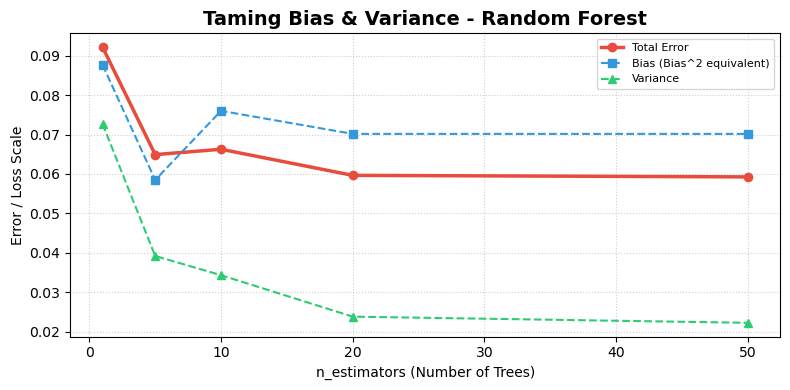

In [18]:
def tame_random_forest(X_train, X_test, y_train, y_test):
    """
    Evaluates a Random Forest by varying 'n_estimators' to demonstrate how 
    ensembling dampens variance.
    """
    # Test from 1 single tree to a small ensemble of 50 trees
    estimator_range = [1, 5, 10, 20, 50]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Random Forest estimators...")
    for n_est in estimator_range:
        model = RandomForestClassifier(n_estimators=n_est, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results
    plot_taming_curves(estimator_range, total_errors, biases, variances, 'n_estimators (Number of Trees)', 'Random Forest')

# Run the taming process for the forest
tame_random_forest(X_train, X_test, y_train, y_test)

2.4.4 MLP

Evaluating MLP alpha values...


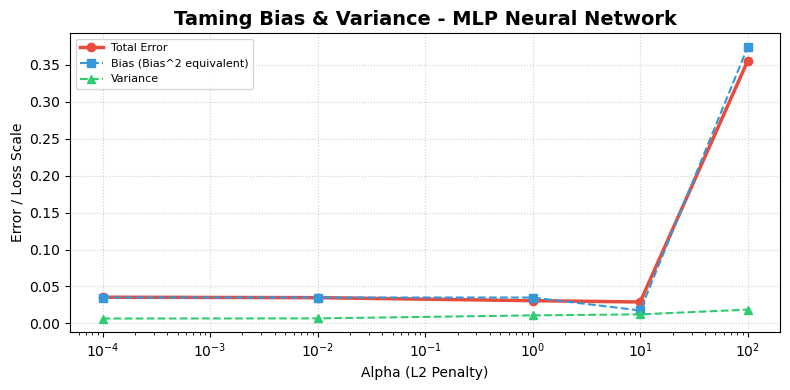

In [19]:
def tame_mlp(X_train, X_test, y_train, y_test):
    """
    Evaluates a Multi-Layer Perceptron by varying the L2 regularization parameter 'alpha'.
    """
    # Test alpha values on a logarithmic scale (from almost no penalty to massive penalty)
    alpha_values = [0.0001, 0.01, 1.0, 10.0, 100.0]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating MLP alpha values...")
    for alpha in alpha_values:
        # Fixed architecture of 30x30 neurons to keep the capacity constant
        model = MLPClassifier(hidden_layer_sizes=(30, 30), alpha=alpha, max_iter=1000, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results using a log scale on the X axis
    plot_taming_curves(alpha_values, total_errors, biases, variances, 'Alpha (L2 Penalty)', 'MLP Neural Network', log_scale=True)

# Run the taming process for the MLP
tame_mlp(X_train, X_test, y_train, y_test)